# Deep Learning
## Actividad 1: Deep Vision

GRUPO 7

Alina Oganesyan  
Celia Vincent  
Orlando Dotollo  

# Actividad Deep Vision

Diseñar y comparar dos estrategias para la clasificación de imágenes en el dataset CIFAR100 de Keras (https://keras.io/api/datasets/cifar100/)

### **Estrategia 1: Red pre-entrenada**

La primera estrategia a comparar debe incluir la utilización de redes preentrenadas con el dataset ImageNet, llevando a cabo tareas de *transfer learning* y *fine-tuning* para clasificar los objetos de CIFAR100. Deben compararse al menos dos tipos de arquitecturas (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet...) y se debe seleccionar la que mayor precisión nos dé (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera que el ejercicio presente una profunda experimentación haciendo uso todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation, etc.).

### **Estrategia 2: Entrenar desde cero o from scratch**

La segunda estrategia a comparar será una red neuronal que se debe diseñar, entrenar y optimizar. Se requiere una justificación empírica de las decisiones que llevaron a la selección de atributos, capas e hiperparámetros a los que se ha llegado. Se espera que el ejercicio presente una profunda experimentación haciendo uso de todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation...).

## Normas a seguir

- Se debe entregar un **ÚNICO GOOGLE COLAB notebook** (archivo .ipynb) que incluya las instrucciones presentes y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso seguido (carga de datos, visualización de datos, proceso de entrenamiento y proceso de validación del modelo).
- Poner el nombre del grupo en el nombre del archivo y el nombre de todos los integrantes del grupo al inicio del notebook.
- Las redes utilizadas deben estar entrenadas y con las métricas extraídas en el conjunto de test.
- Es recomendable crear una última sección de texto en el notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterio de evaluación

- Seguimiento de las normas establecidas en la actividad.
- Efectividad al presentar las comparaciones entre métricas de evaluación de ambos modelos.
- Demostración de la utilización de técnicas de optimización para mejorar el rendimiento de los modelos.
- Modelos predictivos con rendimiento superior al aleatorio.
- Corrección en el uso de algoritmos, modelos y formas idiomáticas en Python.
- El código debe poder ejecutarse sin modificación alguna en Google Colaboratory.

Recomendaciones en el Uso de Colab:

- Eliminar las variables innecesarias para liberar RAM mediante la sentencia:

del nombrevariable

In [1]:
from google.colab import drive
drive.mount('/content/DL')

BASE_FOLDER = '/content/DL' # Ajustar el directorio raíz de Google Drive

Mounted at /content/DL


In [2]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelBinarizer
import random


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

In [4]:
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
#from google.colab import drive

In [ ]:
print(tf.__version__)

2.17.0


In [ ]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
cifar100 = tf.keras.datasets.cifar100
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']


[INFO]: Loading CIFAR-100 data...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imprimir las formas de los datos para verificar
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_test shape: {y_test.shape}')

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [14]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### **Estrategia 1: Red pre-entrenada**

###**Red 1: VGG16**

Como primera red pre-entrenada, elegimos VGG16 por considerarse simple y usar capas convolucionales estándar. Igualmente, aunque la arquitectura sea simple, parece ser pesada, por sus requerimientos de memoria (528MB según la documentación de Keras).

**Acondicionamos los datos de entrenamiento**

Imprimimos los valores mínimos y máximos antes de realizar cualquier cambio para tener una referencia de cómo cambiarán los datos tras el procesamiento

In [ ]:
print(x_train.max())
print(x_train.min())


255
0


Realizamos OHE sobre las etiquetas de test y train.

In [ ]:
print("Forma de y_train antes de la conversión:", y_train.shape)
print("Forma de y_test antes de la conversión:", y_test.shape)

Forma de y_train antes de la conversión: (50000, 1)
Forma de y_test antes de la conversión: (10000, 1)


In [ ]:
lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

In [ ]:
print("Forma de y_train después de la conversión:", y_train.shape)
print("Forma de y_test después de la conversión:", y_test.shape)

Forma de y_train después de la conversión: (50000, 100)
Forma de y_test después de la conversión: (10000, 100)


Importamos la arquitectura VGG16 y aplicamos el preprocesamiento  necesario específicamente para esta red neuronal.

In [ ]:
from tensorflow.keras.applications import vgg16
x_train = vgg16.preprocess_input(x_train)
x_test = vgg16.preprocess_input(x_test)


Comprobamos cómo han cambiado los datos tras el procesamiento.

In [ ]:
print(x_train.max())
print(x_train.min())

151.061
-123.68


**Cargamos el base model**

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet',
                 include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                 input_shape=(32,32,3))
base_model.summary()

  868352/58889256 ━━━━━━━━━━━━━━━━━━━━ 1:06 1us/step

KeyboardInterrupt: 

#### **Transfer Learning**

**Congelando el modelo base y creando el top model**

Primero importamos las clases necesarias y congelamos el base model, es decir, hacemos que sus pesos no se actualicen durante el entrenamiento

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

base_model.trainable = False # Evitar que los pesos se modifiquen en la parte convolucional -> TRANSFER LEARNING

Creamos un nuevo modelo secuencial y lo conectamos con nuestro base model

In [ ]:
pre_trained_model = Sequential()
pre_trained_model.add(base_model)

Ahora, añadimos más capas al nuevo modelo y observamos el resumen de nuestro "top model"

In [ ]:
pre_trained_model.add(layers.Flatten())
pre_trained_model.add(layers.Dense(256, activation='relu'))
pre_trained_model.add(layers.Dense(100, activation='softmax'))

pre_trained_model.summary() #ANTES NO DABA ERROR, PROBAR DE NUEVO EN OTRA SESIÓN

ValueError: Undefined shapes are not supported.

**Entrenando el top model**

In [ ]:
# Entrenando la solución
train(x_train, y_train, x_test, y_test, pre_trained_model, BASE_FOLDER)

- Curvas de entrenamiento:
train_loss: Esta curva muestra la evolución de la pérdida en los datos de entrenamiento. Podemos ver que la pérdida disminuye gradualmente, lo que indica que el modelo está aprendiendo.
train_acc: La curva de precisión de entrenamiento está muy cerca de 0, lo que sugiere que el modelo tiene dificultades para mejorar en la precisión, a pesar de la reducción en la pérdida.
- Curvas de validación:
val_loss: La pérdida en los datos de validación también disminuye inicialmente, pero luego parece estabilizarse y hasta podría estar comenzando a aumentar después de cierto punto, lo que puede ser un indicio de sobreajuste (overfitting).
val_acc: La precisión en los datos de validación también es muy baja, y parece casi plana, lo que sugiere que el modelo no está mejorando su rendimiento en el conjunto de validación.

La gráfica indica que el modelo está reduciendo la pérdida en entrenamiento pero no está mejorando significativamente la precisión. Además, parece estar sobreajustando el conjunto de entrenamiento, ya que la pérdida en validación no sigue disminuyendo de manera consistente.


#### **Fine Tuning**

**Congelamos partes del base model y aplicamos fine tuning**

Empezamos a congelar las capas, ya que las primeras capas de la red aprenden características más genéricas, mientras que las capas posteriores aprenden características más específicas de la tarea.
Congelamos las primeras capas hasta bloque_16, las siguientes capas se usaran para el entrenamiento.

ALGUNAS DE LAS PRUEBAS REALIZADAS

Accuracy: 0.06
- capas congeladas: hasta block_6_expand
- dense: 64
- dropout: 0.5
- learning rate: 0.00001
- epocas: 15

Accuracy: 0.13
- capas congeladas: hasta block_6_expand
- dense: 64
- dropout: 0.5
- learning rate: 0.00001
- epocas: 50

Accuracy: 0.24
- capas congeladas: hasta block_6_expand
- dense: 64
- dropout: 0.5
- learning rate: 0.00001
- epocas: 100 [con early_stopper en el callback] hasta 95

Accuracy: 0.26
- capas congeladas: hasta block_6_expand
- añadimos las siguientes capas:
x = Flatten()(last)
x = Dense(512, activation='relu', name='fc2')(x)
x = Dense(102, activation='softmax', name='predictions')(x)
model = Model(base_model.input, x)
- dense: 64
- dropout: 0.5
- learning rate: 0.00001
- epocas: 100 [con early_stopper en el callback] hasta 49

In [ ]:
# Volvemos a cargar el base_model
base_model = VGG16(weights='imagenet',
                 include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                 input_shape=(32,32,3))

# Congelamos las capas deseadas
for layer in base_model.layers:
  if layer.name == 'block_6_expand':
    break
  layer.trainable = False
  print('Capa ' + layer.name + ' congelada...')

# Compilar el modelo
print("[INFO]: Compilando el modelo...")
pre_trained_model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.00001),
                          metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)

# Entrenamiento de la red
print("[INFO]: Entrenando la red...")
H_pre = pre_trained_model.fit(x_train,
                              y_train,
                              batch_size=128,
                              epochs=15,
                              validation_split=0.2,
                              callbacks=[early_stopping, lr_scheduler])

# Montamos la unidad de Drive
#drive.mount('/content/DL')
# Almacenamos el modelo empleando la función mdoel.save de Keras
#pre_trained_model.save(BASE_FOLDER+"deepCNN_CIFAR100_pretrained.h5")

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = pre_trained_model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

In [ ]:
# Volvemos a cargar el base_model
base_model = VGG16(weights='imagenet',
                 include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                 input_shape=(32,32,3))

# Congelamos las capas deseadas
for layer in base_model.layers:
  if layer.name == 'block_16_expand':
    break
  layer.trainable = False
  print('Capa ' + layer.name + ' congelada...')

# Compilar el modelo
print("[INFO]: Compilando el modelo...")
pre_trained_model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.00001),
                          metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)

# Entrenamiento de la red
print("[INFO]: Entrenando la red...")
H_pre = pre_trained_model.fit(x_train,
                              y_train,
                              batch_size=128,
                              epochs=50,
                              validation_split=0.2,
                              callbacks=[early_stopping, lr_scheduler])

# Montamos la unidad de Drive
#drive.mount('/content/DL')
# Almacenamos el modelo empleando la función mdoel.save de Keras
#pre_trained_model.save(BASE_FOLDER+"deepCNN_CIFAR100_pretrained.h5")

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = pre_trained_model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

In [ ]:
# Volvemos a cargar el base_model
base_model = VGG16(weights='imagenet',
                 include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                 input_shape=(32,32,3))

# Congelamos las capas deseadas
for layer in base_model.layers:
  if layer.name == 'block_16_expand':
    break
  layer.trainable = False
  print('Capa ' + layer.name + ' congelada...')

# Compilar el modelo
print("[INFO]: Compilando el modelo...")
pre_trained_model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.00001),
                          metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)

# Entrenamiento de la red
print("[INFO]: Entrenando la red...")
H_pre = pre_trained_model.fit(x_train,
                              y_train,
                              batch_size=128,
                              epochs=100,
                              validation_split=0.2,
                              callbacks=[early_stopping, lr_scheduler])

# Montamos la unidad de Drive
#drive.mount('/content/DL')
# Almacenamos el modelo empleando la función mdoel.save de Keras
#pre_trained_model.save(BASE_FOLDER+"deepCNN_CIFAR100_pretrained.h5")

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = pre_trained_model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

In [ ]:
# Volvemos a cargar el base_model
base_model = VGG16(weights='imagenet',
                 include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                 input_shape=(32,32,3))

# Congelamos las capas deseadas
for layer in base_model.layers:
  if layer.name == 'block_16_expand':
    break
  layer.trainable = False
  print('Capa ' + layer.name + ' congelada...')

# Usamos la API funcional
last = base_model.layers[-1].output
x = Flatten()(last)
x = Dense(512, activation='relu', name='fc2')(x)
x = Dense(102, activation='softmax', name='predictions')(x)
model = Model(base_model.input, x)

# Compilar el modelo
print("[INFO]: Compilando el modelo...")
pre_trained_model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.00001),
                          metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)

# Entrenamiento de la red
print("[INFO]: Entrenando la red...")
H_pre = pre_trained_model.fit(x_train,
                              y_train,
                              batch_size=128,
                              epochs=100,
                              validation_split=0.2,
                              callbacks=[early_stopping, lr_scheduler])

# Montamos la unidad de Drive
#drive.mount('/content/DL')
# Almacenamos el modelo empleando la función mdoel.save de Keras
#pre_trained_model.save(BASE_FOLDER+"deepCNN_CIFAR100_pretrained.h5")

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = pre_trained_model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

####Conclusiones

Después de las pruebas con el eraly_stopper, añadiendo distintas capas y disminuyendo el learning_rate, hemos visto que el modelo ha mejorado desde un accuracy de 0.06 inicial a 0.26 final.

Además, el accuracy parece subir y en el gráfico aparecen cambios ligeramente susceptibles indicando también una mejora en el overfitting y entrenamiento del modelo.


###**Red 2: Xception**


Como segunda red pre-entrenada, elegimos MobileNet por tener una arquitectura muy distinta a la de VGG16, y considerarse un modelo más eficiente (cosa que también comprobamos al mirar sus requerimientos de memoria que en la documentación de Keras son 16MB)

Importamos la arquitectura MobileNet. El preprocesamiento realizado sobre el dataset anteriormente nos sirve también para este modelo (preprocesamiento + OHE), por lo que no hace falta repetirlo.

In [16]:
from tensorflow.keras.applications import Xception
import tensorflow as tf
from tensorflow.image import resize
from tensorflow.keras import layers, models
from tensorflow.keras.applications import Xception
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

**Cargamos el base model**

In [17]:
# Cargar y preprocesar los datos CIFAR-100
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

#### **Transfer Learning**

** Redimensionar imagenes y normalizar datos**


In [18]:
# Redimensionar las imágenes a 71x71 para que coincidan con la entrada mínima requerida por Xception
x_train = tf.image.resize(x_train, (71, 71))
x_test = tf.image.resize(x_test, (71, 71))

# Normalizar los datos
x_train = tf.cast(x_train, tf.float32) / 255.0 # Use tf.cast to convert to float32
x_test = tf.cast(x_test, tf.float32) / 255.0  # Use tf.cast to convert to float32

# Convertir las etiquetas a una codificación categórica
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

# Cargar el modelo Xception preentrenado sin la capa superior
base_model = Xception(weights='imagenet', include_top=False, input_shape=(71, 71, 3))

**Congelando el modelo base y creando el top model**

In [19]:
# Congelar las capas del modelo base
base_model.trainable = False

# Crear el modelo completo
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dense(100, activation='softmax')
])

**Compilando el modelo, entrenamos y evaluamos**

In [20]:
# Compilar el modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
H_pre = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

# Evaluar el modelo
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.3033 - loss: 2.9720 - val_accuracy: 0.4217 - val_loss: 2.2249
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4798 - loss: 1.9722 - val_accuracy: 0.4470 - val_loss: 2.1659
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5543 - loss: 1.6385 - val_accuracy: 0.4494 - val_loss: 2.2352
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6247 - loss: 1.3632 - val_accuracy: 0.4448 - val_loss: 2.3582
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6848 - loss: 1.1303 - val_accuracy: 0.4370 - val_loss: 2.5416
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7361 - loss: 0.9358 - val_accuracy: 0.4335 - val_loss: 2.7328
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7830 - loss: 0.7697 - val_accuracy: 0.4276 - val_loss: 2.9768
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8181 -

**Predicción y reporte de la evaluación**

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step
               precision    recall  f1-score   support

        apple       0.70      0.74      0.72       100
aquarium_fish       0.48      0.60      0.53       100
         baby       0.30      0.29      0.29       100
         bear       0.17      0.13      0.15       100
       beaver       0.20      0.29      0.24       100
          bed       0.52      0.32      0.40       100
          bee       0.32      0.47      0.38       100
       beetle       0.58      0.26      0.36       100
      bicycle       0.74      0.48      0.58       100
       bottle       0.65      0.53      0.59       100
         bowl       0.46      0.33      0.39       100
          boy       0.19      0.46      0.27       100
       bridge       0.54      0.50      0.52       100
          bus       0.55      0.22      0.31       100
    butterfly       0.37      0.32      0.34       100
        camel       0.42      0.31      0.36       100
          can       0.38

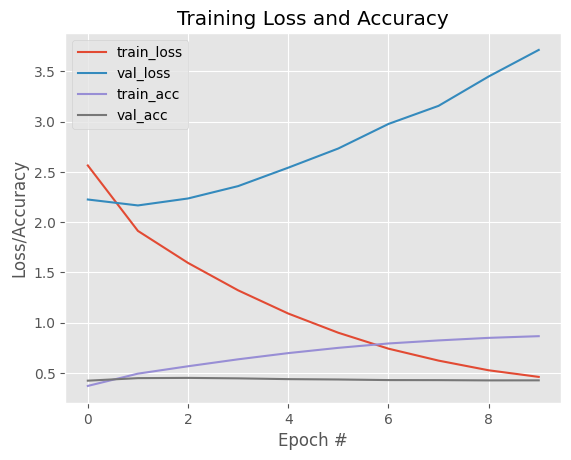

In [21]:
# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = model.predict(x_test, batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

## Fine-tuning

Capa input_layer_8 congelada...
Capa block1_conv1 congelada...
Capa block1_conv1_bn congelada...
Capa block1_conv1_act congelada...
Capa block1_conv2 congelada...
Capa block1_conv2_bn congelada...
Capa block1_conv2_act congelada...
Capa block2_sepconv1 congelada...
Capa block2_sepconv1_bn congelada...
Capa block2_sepconv2_act congelada...
Capa block2_sepconv2 congelada...
Capa block2_sepconv2_bn congelada...
Capa conv2d_24 congelada...
Capa block2_pool congelada...
Capa batch_normalization_24 congelada...
Capa add_72 congelada...
Capa block3_sepconv1_act congelada...
Capa block3_sepconv1 congelada...
Capa block3_sepconv1_bn congelada...
Capa block3_sepconv2_act congelada...
Capa block3_sepconv2 congelada...
Capa block3_sepconv2_bn congelada...
Capa conv2d_25 congelada...
Capa block3_pool congelada...
Capa batch_normalization_25 congelada...
Capa add_73 congelada...
Capa block4_sepconv1_act congelada...
Capa block4_sepconv1 congelada...
Capa block4_sepconv1_bn congelada...
Capa block4_s

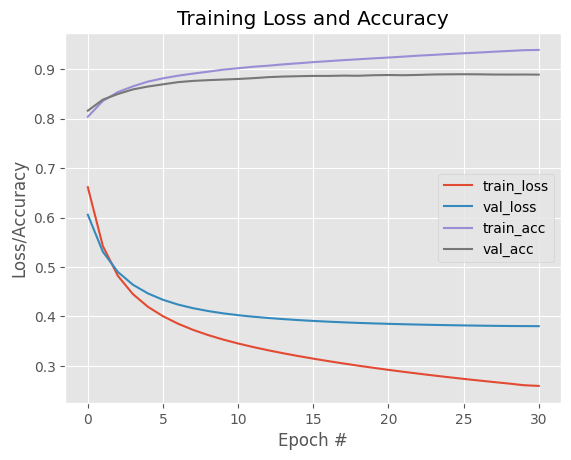

In [22]:
# Volvemos a cargar el base_model
base_model = Xception(weights='imagenet',
                 include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                 input_shape=(71, 71, 3))

# Congelamos las capas deseadas
for layer in base_model.layers:
  if layer.name == 'block_16_expand':
    break
  layer.trainable = False
  print('Capa ' + layer.name + ' congelada...')

# Compilar el modelo
print("[INFO]: Compilando el modelo...")
model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.00001),
                          metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)

# Volvemos a entrenar la red
print("[INFO]: Entrenando la red...")
H_pre = model.fit(x_train,
                              y_train,
                              epochs=50,
                              batch_size=128,
                              validation_split=0.2,
                              callbacks=[early_stopping, lr_scheduler]
                              )
 # Montamos la unidad de Drive
##rive.mount('/content/DL')

# Almacenamos el modelo empleando la función mdoel.save de Keras
#pre_trained_model.save(BASE_FOLDER+"deepCNN_CIFAR100_pretrained_fine_tuned.h5")

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

Con el modelo Xception (accuracy: 0,43) hemos conseguido aumentar el accuracy en la predicción con respecto al modelo VGG16 (accuracy: 0,06).
Con el fine tunning en el modelo VGG16 conseguimos un accuracy de 0,26 y fijando los mismos parámetros para el modelo Xception hemos conseguido un accuracy de 0,46.

In [ ]:
break

### **Estrategia 2: Entrenar desde cero o from scratch**

In [23]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


#### **- Importación de librarías**

In [24]:
# Import the necessary packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tarfile
import pickle
import random
%matplotlib inline

from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

#### **- Definición de las funciones de entrenamiento**

In [25]:
# Función de entrenamiento sin aplicar data augmentation
def train(x_train, y_train, x_test, y_test, pre_trained_model, BASE_FOLDER, learn_rate=0.0005):
  # Resumen del modelo
  pre_trained_model.summary()

  # Compilar el modelo
  print("[INFO]: Compilando el modelo...")
  pre_trained_model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=learn_rate), metrics=["accuracy"])

  # Entrenamiento de la red
  print("[INFO]: Entrenando la red...")
  H_pre = pre_trained_model.fit(x_train, y_train, batch_size=128, epochs=20, validation_split=0.2) # Destinamos 20% a validación
  # Almaceno el modelo en Drive
  # Almacenamos el modelo empleando la función mdoel.save de Keras
  pre_trained_model.save(BASE_FOLDER+"deepCNN_CALTECH101_pretrained.h5")

  # Evaluación del modelo
  print("[INFO]: Evaluando el modelo...")
  # Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
  predictions = pre_trained_model.predict(x_test, batch_size=128)
  # Sacamos el report para test
  print(classification_report(y_test.argmax(axis=1), predictions.argmax(axis=1), target_names=labelNames))

  # Gráficas
  plt.style.use("ggplot")
  plt.figure()
  plt.plot(np.arange(0, 20), H_pre.history["loss"], label="train_loss")
  plt.plot(np.arange(0, 20), H_pre.history["val_loss"], label="val_loss")
  plt.plot(np.arange(0, 20), H_pre.history["accuracy"], label="train_acc")
  plt.plot(np.arange(0, 20), H_pre.history["val_accuracy"], label="val_acc")
  plt.title("Training Loss and Accuracy")
  plt.xlabel("Epoch #")
  plt.ylabel("Loss/Accuracy")
  plt.legend()
  plt.show()


# Función de entrenamiento aplicando data augmentation
def train_with_datagen(x_train, y_train, x_test, y_test, model_aug, BASE_FOLDER, data_aug_factor, train_datagen, learn_rate=0.0005, epochs=20):
  # Resumen del modelo
  model.summary()

  # Entrenando la solución con data augmentation
  train_generator = train_datagen.flow(
    x_train,
    y_train,
    batch_size=128,
    subset= 'training' # (X) INPUT - Definir la partición de entrenamiento
  )

  validation_generator = datagen.flow(
    trainX,
    trainY,
    batch_size=128,
    subset= 'validation' # (X) IMPUT - Definir la partición de validación
  )

  # Compilar el modelo
  print("[INFO]: Compilando el modelo...")
  model.compile(loss="categorical_crossentropy", optimizer=Adam(lr=learn_rate,decay=0, beta_1=0.9, beta_2=0.999, epsilon=1e-08), metrics=["accuracy"])

  # Entrenamiento de la red
  print("[INFO]: Entrenando la red...")

  H_aug = model.fit(
            train_generator,
            steps_per_epoch = train_generator.n*data_aug_factor//128,
            validation_data = validation_generator,
            validation_steps = validation_generator.n*data_aug_factor//128,
            workers = data_aug_factor,
            epochs = epochs)

  # Almacenos el modelo en Drive
  # Montamos la unidad de Drive
  drive.mount('/content/drive')
  # Almacenamos el modelo empleando la función mdoel.save de Keras
  model.save(BASE_FOLDER+"deepCNN_CALTECH101_pretrained.h5")

  # Evaluación del modelo
  print("[INFO]: Evaluando el modelo...")
  # Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
  predictions = model.predict(x_test, batch_size=128)
  # Sacamos el report para test
  print(classification_report(y_test.argmax(axis=1), predictions.argmax(axis=1), target_names=labelNames))

  # Gráficas
  plt.style.use("ggplot")
  plt.figure()
  plt.plot(np.arange(0, 20), H_aug.history["loss"], label="train_loss")
  plt.plot(np.arange(0, 20), H_aug.history["val_loss"], label="val_loss")
  plt.plot(np.arange(0, 20), H_aug.history["accuracy"], label="train_acc")
  plt.plot(np.arange(0, 20), H_aug.history["val_accuracy"], label="val_acc")
  plt.title("Training Loss and Accuracy")
  plt.xlabel("Epoch #")
  plt.ylabel("Loss/Accuracy")
  plt.legend()
  plt.show()

#### **- Cargando el conjunto de datos**

In [26]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
cifar100 = tf.keras.datasets.cifar100
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']


[INFO]: Loading CIFAR-100 data...


In [27]:
path = BASE_FOLDER

os.chdir(path)

folders = os.listdir()
folder_paths = []
all_images = []
all_classes = []
img_size = 128

OSError: [Errno 107] Transport endpoint is not connected: '/content/DL'

#### **- Inspeccionando el conjunto de datos**

In [ ]:
print(x.shape)
print(len(y_str))

# show image
i = 9144
imgplot = plt.imshow(x[i])
plt.show()
print("La clase es %s" %(y_str[i]))

In [ ]:
fig = plt.figure(figsize=(14,10))

for n, i in enumerate(random.sample(range(1,len(y_str)), 28)):
    fig.add_subplot(4, 7, n+1)
    img = x[i]
    plt.imshow(img)
    plt.title(y_str[i])
    plt.axis('off')

Según la página oficial (http://www.vision.caltech.edu/Image_Datasets/Caltech101/) existen un rango de 40 a 800 imágenes por clase, teniendo la mayoría de estas, 50 imágenes.

Vamos a comprobarlo...

In [ ]:
plt.rcParams.update({'figure.figsize':(15,5), 'figure.dpi':120})

# Plot Histogram on x
plt.hist(y_str, bins=range(0,103), width=0.9, align='left')
plt.xticks(rotation = 90, size=6)
plt.gca().set(title='Número de muestras por clase', ylabel='Número de muestras')

In [ ]:
Se observa una clara distribución desbalanceada de las muestras. Efectivamente, se observa que la clase con mayores muestras ronda las 800 miestras que las muestras con menores muestras rondan las 40.

In [ ]:
# Visualizamos el número de muestras de una clase en particular
label_name = "Motorbikes"
count = 0
for label in y_str:
  if label == label_name:
    count += 1

print(count)

In [ ]:
# Visualizamos todas las muestras de una clase en particular
label_name = "garfield"

plt.rcParams.update({'figure.figsize':(2,2), 'figure.dpi':128})
for i, label in enumerate(y_str):
  if label == label_name:
    imgplot = plt.imshow(x[i])
    plt.show()

Se observa que muchas son muy parecidas o idénticas, lo que puede provocar overfitting.

#### **- Acondicionando el conjunto de datos**